--- Proporção Original das Classes ---
Bons pagadores (Classe 0): 1717
Inadimplentes  (Classe 1): 283
Utilizando Unique: (array([0, 1]), array([1717,  283]))

--- Após aplicar Tomek Links (Dados de Treino) ---
X_treino original: 1600 linhas
X_treino após Tomek Links: 1595 linhas
Bons pagadores removidos da fronteira: 5

----- AVALIAÇÃO DO MODELO COM TOMEK LINKS -----
Acurácia Global: 91.25%

Matriz de Confusão:
[[336   7]
 [ 28  29]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       343
           1       0.81      0.51      0.62        57

    accuracy                           0.91       400
   macro avg       0.86      0.74      0.79       400
weighted avg       0.91      0.91      0.90       400



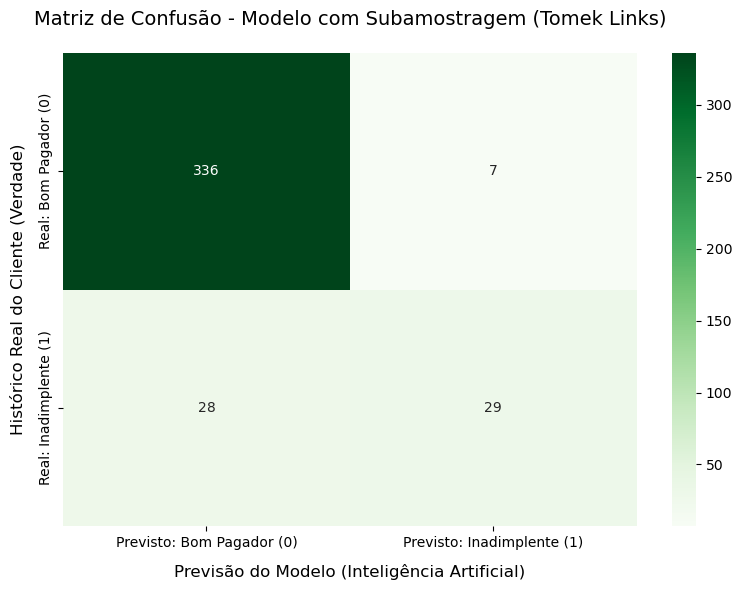

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
# Importação da biblioteca específica para balanceamento de dados
from imblearn.under_sampling import TomekLinks

# ==========================================
# 1. CARREGAMENTO E TRATAMENTO DOS DADOS
# ==========================================

df = pd.read_csv('credit_data.csv')

# Limpando caracteres especiais dos nomes das colunas
df.columns = df.columns.str.replace('#', '').str.strip()

# Tratando inconsistências: idades negativas viram nulas
df.loc[df['age'] < 0, 'age'] = np.nan
# Preenchendo valores nulos com a média da idade
df['age'] = df['age'].fillna(df['age'].mean())

# Separando variáveis preditoras (X) e alvo (y)
X = df[['income', 'age', 'loan']].values
y = df['cdefault'].values

print("--- Proporção Original das Classes ---")
print(f"Bons pagadores (Classe 0): {np.bincount(y)[0]}")
print(f"Inadimplentes  (Classe 1): {np.bincount(y)[1]}")
print(f"Utilizando Unique: {np.unique(y, return_counts=True)}") #contagem de 0 e 1, podendo utilizar bitcount


# ==========================================
# 2. DIVISÃO EM TREINO E TESTE
# ==========================================
# IMPORTANTE: O balanceamento DEVE ser feito APENAS nos dados de treino.
# Se balancearmos o teste, criaremos uma avaliação artificial que não reflete o mundo real.
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ==========================================
# 3. PADRONIZAÇÃO (Essencial para Tomek Links)
# ==========================================
# Como o Tomek Links calcula a distância geométrica (vizinho mais próximo), 
# os dados PRECISAM estar na mesma escala antes de aplicar a técnica.
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

# ==========================================
# 4. APLICAÇÃO DO TOMEK LINKS (Subamostragem)
# ==========================================

# Criamos o objeto do Tomek Links
# O parâmetro sampling_strategy='auto' indica que ele removerá apenas elementos da classe majoritária
tl = TomekLinks(sampling_strategy='auto')

# Aplicamos a técnica EXCLUSIVAMENTE no conjunto de treino escalado
X_treino_balanceado, y_treino_balanceado = tl.fit_resample(X_treino_scaled, y_treino)

print("\n--- Após aplicar Tomek Links (Dados de Treino) ---")
print(f"X_treino original: {X_treino_scaled.shape[0]} linhas")
print(f"X_treino após Tomek Links: {X_treino_balanceado.shape[0]} linhas")
print(f"Bons pagadores removidos da fronteira: {X_treino_scaled.shape[0] - X_treino_balanceado.shape[0]}")

# ==========================================
# 5. TREINAMENTO DO MODELO (NAIVE BAYES)
# ==========================================

modelo_nb = GaussianNB()
# Treinamos o modelo com os dados que passaram pelo filtro do Tomek Links
modelo_nb.fit(X_treino_balanceado, y_treino_balanceado)

# Previsões usando os dados de teste (que mantiveram a escala original do mundo real)
y_pred = modelo_nb.predict(X_teste_scaled)

# ==========================================
# 6. AVALIAÇÃO DO MODELO RESULTANTE
# ==========================================

print("\n----- AVALIAÇÃO DO MODELO COM TOMEK LINKS -----")
print(f"Acurácia Global: {accuracy_score(y_teste, y_pred) * 100:.2f}%")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_teste, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_pred))

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Gerar a matriz de confusão com o modelo treinado via Tomek Links
# (Utilizando as previsões 'y_pred' que geramos no bloco anterior)
cm_tomek = confusion_matrix(y_teste, y_pred)

# 2. Configurar o visual do gráfico
plt.figure(figsize=(8, 6))

# Criamos o mapa de calor focado no modelo balanceado
# Mudamos a paleta para 'Greens' para diferenciar visualmente do primeiro gráfico no seu relatório
sns.heatmap(cm_tomek, annot=True, fmt='d', cmap='Greens', cbar=True,
            xticklabels=['Previsto: Bom Pagador (0)', 'Previsto: Inadimplente (1)'],
            yticklabels=['Real: Bom Pagador (0)', 'Real: Inadimplente (1)'])

# 3. Títulos e rótulos corporativos
plt.title('Matriz de Confusão - Modelo com Subamostragem (Tomek Links)', fontsize=14, pad=20)
plt.xlabel('Previsão do Modelo (Inteligência Artificial)', fontsize=12, labelpad=10)
plt.ylabel('Histórico Real do Cliente (Verdade)', fontsize=12, labelpad=10)

# Exibe o gráfico
plt.tight_layout()
plt.show()
